In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/country_wise_latest.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/day_wise.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/usa_county_wise.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/worldometer_data.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/full_grouped.csv


In [2]:
import pandas as pd

caminho="/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv"
df=pd.read_csv(caminho)
linhas,colunas=df.shape
print(f"Dimensão: {linhas} linhas e {colunas} colunas\n")

print("Nomes das colunas:")
print(df.columns.tolist())
print()
print('Tipo de dado:')
print(df.dtypes)
print()
df["Date"]=pd.to_datetime(df["Date"])
print(df["Date"].dtype)
print()
print('Resumo estatístico')
display(df.describe())
print('Quantidade de valores nulos(NaN)por coluna:')
nulos=df.isnull().sum()
print(nulos)






Dimensão: 49068 linhas e 10 colunas

Nomes das colunas:
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']

Tipo de dado:
Province/State     object
Country/Region     object
Lat               float64
Long              float64
Date               object
Confirmed           int64
Deaths              int64
Recovered           int64
Active              int64
WHO Region         object
dtype: object

datetime64[ns]

Resumo estatístico


,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


Quantidade de valores nulos(NaN)por coluna:
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64


In [3]:
provincias=df[df["Country/Region"]=="China"]["Province/State"].unique()
print('Provincias da China:')
print(provincias)
df_china=df[df['Country/Region']=='China']

data_recente=df_china['Date'].max()
df_china_recente=df_china[df_china['Date']==data_recente]
df_china_cols=df_china_recente[['Province/State','Confirmed','Active','Deaths','Recovered']]

df_china_grouped=df_china_cols.groupby('Province/State').sum()

top5=df_china_grouped.sort_values(by='Confirmed',ascending=False).head(5)
print('\n(e) 5 províncias com mais casos:')
display(top5)


Provincias da China:
['Anhui' 'Beijing' 'Chongqing' 'Fujian' 'Gansu' 'Guangdong' 'Guangxi'
 'Guizhou' 'Hainan' 'Hebei' 'Heilongjiang' 'Henan' 'Hong Kong' 'Hubei'
 'Hunan' 'Inner Mongolia' 'Jiangsu' 'Jiangxi' 'Jilin' 'Liaoning' 'Macau'
 'Ningxia' 'Qinghai' 'Shaanxi' 'Shandong' 'Shanghai' 'Shanxi' 'Sichuan'
 'Tianjin' 'Tibet' 'Xinjiang' 'Yunnan' 'Zhejiang']

(e) 5 províncias com mais casos:


,Confirmed,Active,Deaths,Recovered
Province/State,,,,
Hubei,68135,0,4512,63623
Hong Kong,2778,1270,22,1486
Guangdong,1672,19,8,1645
Henan,1276,1254,22,0
Zhejiang,1270,1,1,1268


In [13]:

def unificar(linha):
    pais=linha['Country/Region']
    provincia=linha['Province/State']
    if pd.notna(provincia) and provincia !='':
        return f'{pais} {provincia}'
    else: 
        return pais

df_copia=df.copy()

df_copia['Country/Region']=df_copia.apply(unificar,axis=1)

df_copia=df_copia.drop(columns=['Province/State'])

print('Dataset')
display(df_copia.head())

Dataset


,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [5]:
cam_world='/kaggle/input/datasets/imdevskp/corona-virus-report/worldometer_data.csv'
df_world=pd.read_csv(cam_world)

df_pop=df_world[['Country/Region','Population','Continent']]

data_max=df_copia['Date'].max()
df_covid=df_copia[df_copia['Date']==data_max]
df_covid_pais=(df_covid.groupby('Country/Region')["Deaths"].sum().reset_index())

df_merged = pd.merge(df_covid_pais, df_pop, on="Country/Region")
df_merged = df_merged[["Country/Region", "Deaths", "Population", "Continent"]]

df_continente = (df_merged.groupby("Continent")[["Deaths", "Population"]].sum().reset_index())

df_continente["Deaths_per_Million"] = (df_continente["Deaths"] / df_continente["Population"]) * 1e6

ranking_continentes = df_continente.sort_values(by="Deaths_per_Million", ascending=False)

print("Ranking de Mortes por Milhão de Habitantes por Continente:")
display(ranking_continentes)

Ranking de Mortes por Milhão de Habitantes por Continente:


,Continent,Deaths,Population,Deaths_per_Million
5,South America,135506,4.308076e+08,314.539491
4,North America,50271,2.190365e+08,229.509685
3,Europe,155640,6.794130e+08,229.080088
1,Asia,85740,3.020510e+09,28.385939
0,Africa,17759,1.215738e+09,14.607591
2,Australia/Oceania,22,1.486220e+07,1.480265


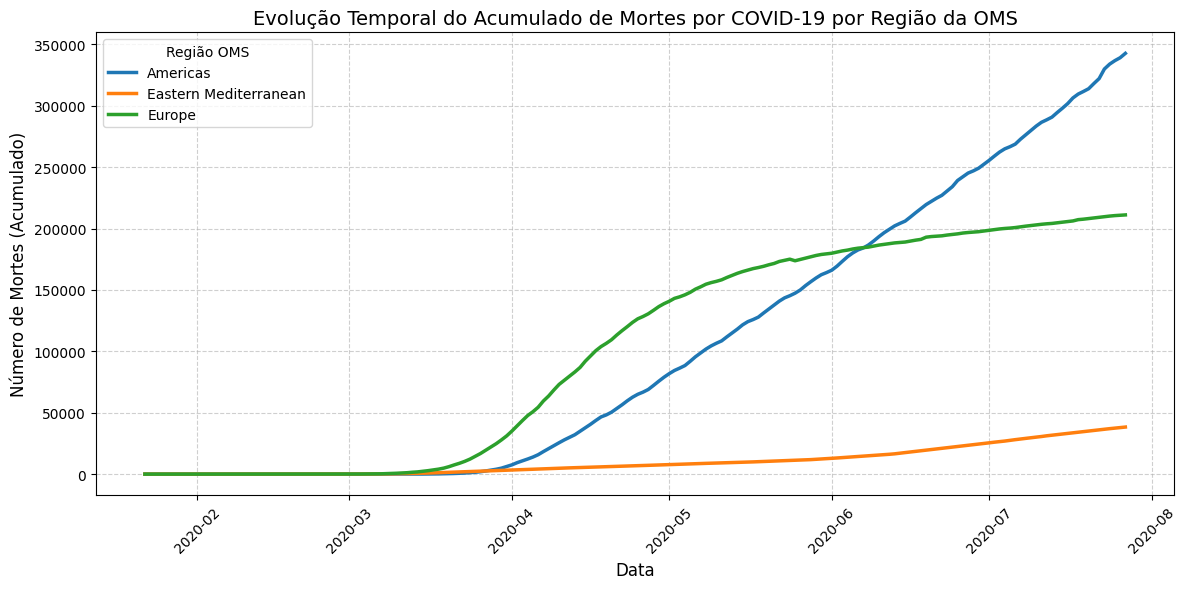

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuração para exibição direta no notebook
%matplotlib inline

# Carregar o dataset
df['Date'] = pd.to_datetime(df['Date'])

# (b) Agrupar os dados por Data e WHO Region, somando as mortes
df_region_time = df.groupby(['Date', 'WHO Region'])['Deaths'].sum().reset_index()

# Filtrar para as 3 regiões especificadas
regioes = ['Eastern Mediterranean', 'Americas', 'Europe']
df_filtrado = df_region_time[df_region_time['WHO Region'].isin(regioes)]

# (c) e (d) Plotar o gráfico de linhas com rótulos e estilo
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtrado, x='Date', y='Deaths', hue='WHO Region', linewidth=2.5)

plt.title('Evolução Temporal do Acumulado de Mortes por COVID-19 por Região da OMS', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Mortes (Acumulado)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Região OMS', fontsize=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

1. Qual região apresentou maior número de mortes acumuladas? Américas
2. Em que período a curva de mortes começou a crescer significativamente em cada
região?
Europa: março/abril 2020
Americas: abril 2020
Eastern Mediterranean:maio 2020
3. Como se comporta a taxa de crescimento das curvas?
Américas: A taxa de crescimento se manteve alta e constante a partir de abril. O fato de a linha continuar subindo de forma íngreme e linear (em um gráfico de valores acumulados) indica que o número de novas mortes diárias continuou alto e constante durante todo o período, sem sinais de achatamento da curva até agosto.

Europa: Apresentou uma taxa de crescimento altíssima inicial (curva bastante vertical em abril), mas a taxa começou a desacelerar progressivamente a partir de junho (a curva começa a "achatar", o que indica que o número de novas mortes por dia diminuiu bastante em relação ao pico).

Eastern Mediterranean: A taxa de crescimento manteve-se baixa e estável ao longo de todo o período analisado. A curva sobe lentamente, indicando um aumento gradual e sem o comportamento explosivo visto nas outras duas regiões nesse recorte de tempo.

/tmp/ipykernel_58/574398691.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_barras, x='Continent', y='TotalDeaths', palette='viridis')


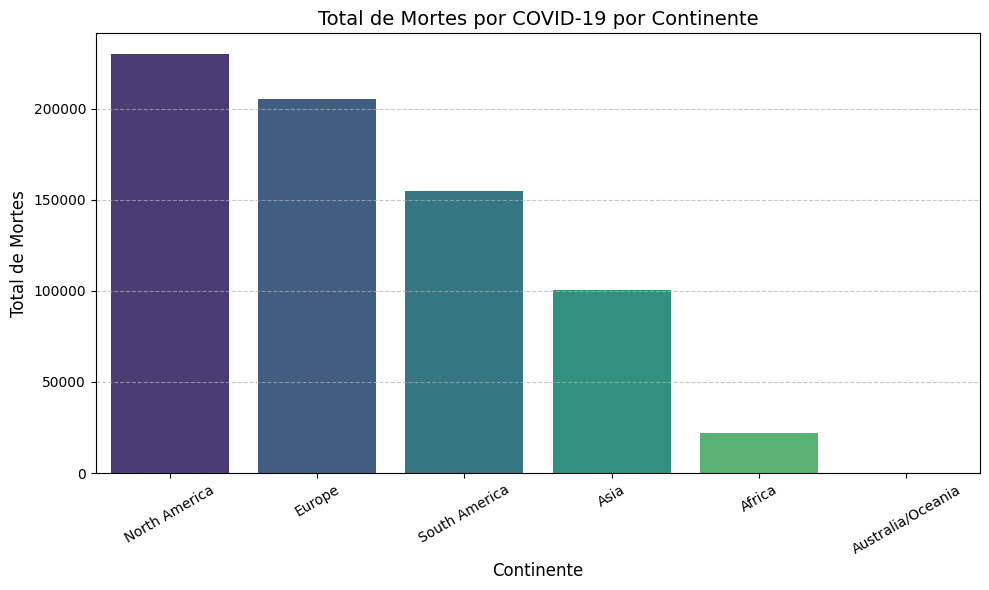

In [7]:


# Agrupando mortes totais mais recentes por continente
df_barras = df_world.groupby('Continent')['TotalDeaths'].sum().reset_index()
df_barras = df_barras.sort_values(by='TotalDeaths', ascending=False)

# (a), (b) e (c) Criar gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_barras, x='Continent', y='TotalDeaths', palette='viridis')

plt.title('Total de Mortes por COVID-19 por Continente', fontsize=14)
plt.xlabel('Continente', fontsize=12)
plt.ylabel('Total de Mortes', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1. Quais são os dois continentes com maior número de mortes?América do norte e eruropa.
2. Qual continente apresentou o menor número de mortes? Oceania
3. Qual sua hipótese para explicar os resultados observados? América do norte e Europa tem muita circulação de pessoas e aviões enquanto a oceania é mais isolada.

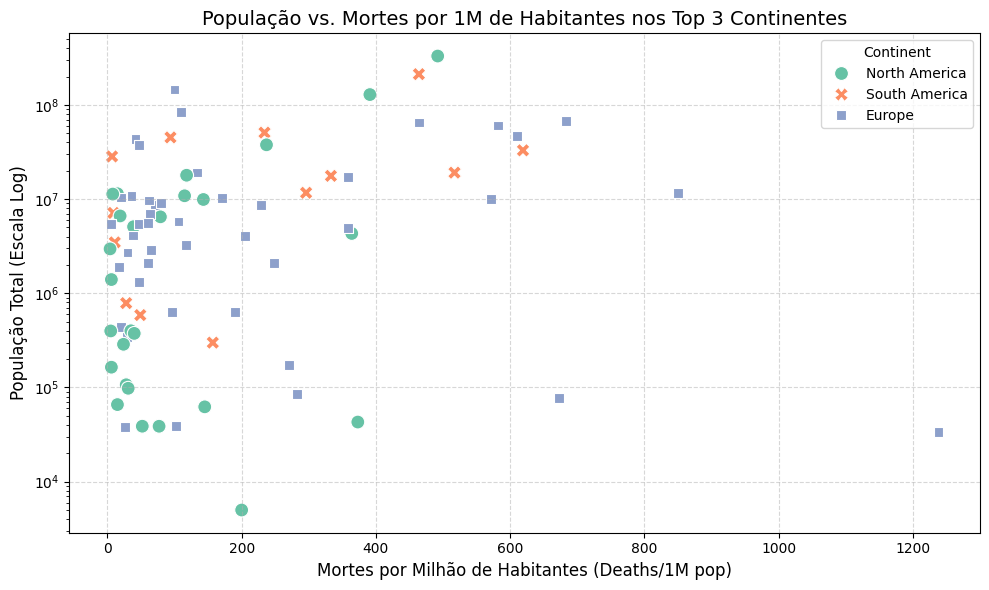

In [8]:
# (a) Identificar os 3 continentes com maior média de "Deaths/1M pop"
top3_continentes = (
    df_world.groupby("Continent")["Deaths/1M pop"]
    .mean()
    .nlargest(3)
    .index.tolist()
)

# (b) Filtrar os dados originais para esses 3 continentes
df_scatter = df_world[
    df_world["Continent"].isin(top3_continentes)
]

# (c) Plotar gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_scatter,
    x="Deaths/1M pop",
    y="Population",
    hue="Continent",
    style="Continent",
    s=100,
    palette="Set2",
)

plt.title(
    "População vs. Mortes por 1M de Habitantes nos Top 3 Continentes",
    fontsize=14,
)
plt.xlabel("Mortes por Milhão de Habitantes (Deaths/1M pop)", fontsize=12)
plt.ylabel("População Total (Escala Log)", fontsize=12)
plt.yscale("log")  # Escala logarítmica para lidar com discrepâncias populacionais
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

1.Sim, há concentração de dados. A grande maioria dos pontos está fortemente agrupada no lado esquerdo do gráfico, especificamente na faixa entre 0 e 200 mortes por milhão de habitantes.
2.Não é possível observar uma tendência. A nuvem de pontos é bastante dispersa e não forma nenhum padrão direcional (como uma linha reta ou curva ascendente/descendente).
3.Não existe relação (correlação) perceptível. O tamanho da população total de um país não se mostra associado a uma maior ou menor taxa de mortes por milhão.

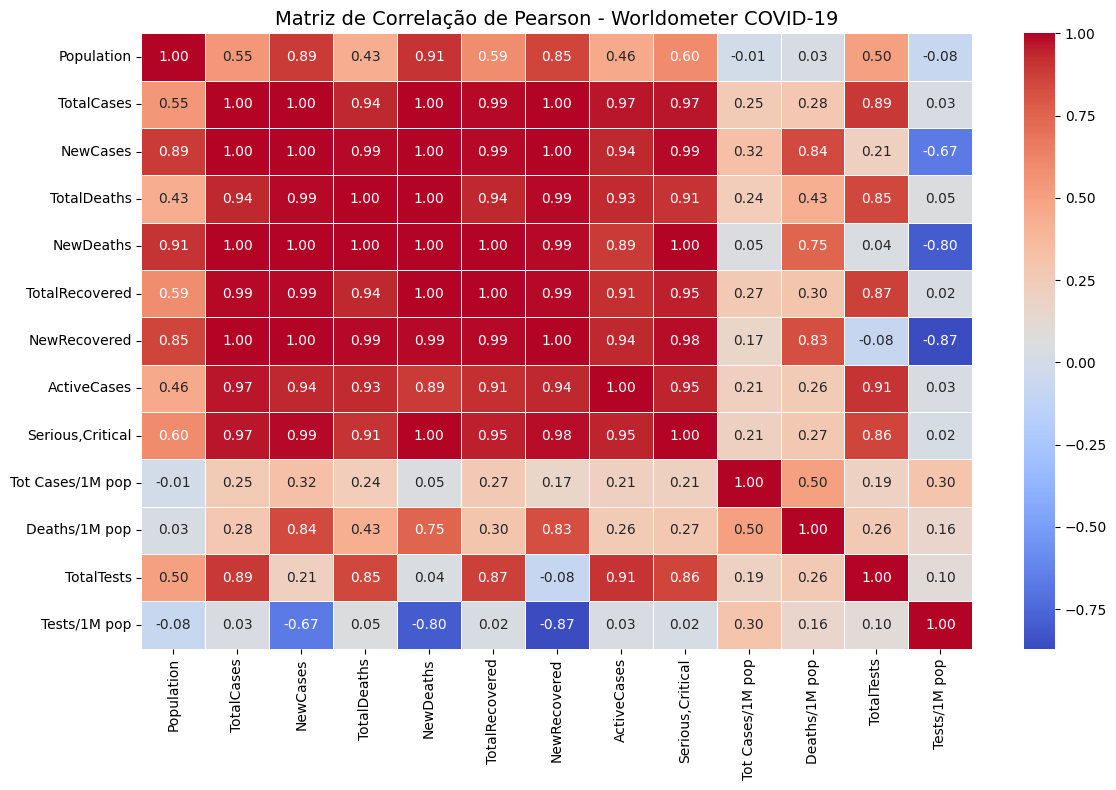

In [9]:
# (a) Selecionar apenas colunas numéricas e calcular a matriz de correlação
colunas_numericas = df_world.select_dtypes(include=['float64', 'int64'])
# (b) Matriz de correlação
matriz_corr = colunas_numericas.corr()

# (c) Criar o heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=True)

plt.title('Matriz de Correlação de Pearson - Worldometer COVID-19', fontsize=14)
plt.tight_layout()
plt.show()